| **ID**| **Name**| 
|-|-|
| 22280075     | Huynh Thao Quynh  | 
| 22280091 | Nguyen Ngoc Thanh Thu  | 

# **Final Project**

## **Problem stament :**     

The widespread dissemination of fake news and propaganda presents serious societal risks, including the erosion of public trust, political polarization, manipulation of elections, and the spread of harmful misinformation during crises such as pandemics or conflicts. From an NLP perspective, detecting fake news is fraught with challenges. Linguistically, fake news often mimics the tone and structure of legitimate journalism, making it difficult to distinguish using surface-level features. The absence of reliable and up-to-date labeled datasets, especially across multiple languages and regions, hampers the effectiveness of supervised learning models. Additionally, the dynamic and adversarial nature of misinformation means that malicious actors constantly evolve their language and strategies to bypass detection systems. Cultural context, sarcasm, satire, and implicit bias further complicate automated analysis. Moreover, NLP models risk amplifying biases present in training data, leading to unfair classifications and potential censorship of legitimate content. These challenges underscore the need for cautious, context-aware approaches, as the failure to address them can inadvertently contribute to misinformation, rather than mitigate it.



Use datasets in link : https://drive.google.com/drive/folders/1mrX3vPKhEzxG96OCPpCeh9F8m_QKCM4z?usp=sharing
to complete requirement.

## **About dataset:**

* **True Articles**:

  * **File**: `MisinfoSuperset_TRUE.csv`
  * **Sources**:

    * Reputable media outlets like **Reuters**, **The New York Times**, **The Washington Post**, etc.

* **Fake/Misinformation/Propaganda Articles**:

  * **File**: `MisinfoSuperset_FAKE.csv`
  * **Sources**:

    * **American right-wing extremist websites** (e.g., Redflag Newsdesk, Breitbart, Truth Broadcast Network)
    * **Public dataset** from:

      * Ahmed, H., Traore, I., & Saad, S. (2017): "Detection of Online Fake News Using N-Gram Analysis and Machine Learning Techniques" *(Springer LNCS 10618)*



## **Requirement**

A team consisting of three members must complete a project that involves applying the methods learned from the beginning of the course up to the present. The team is expected to follow and document the entire machine learning workflow, which includes the following steps:

1. **Data Preprocessing**: Clean and prepare the dataset,etc.

2. **Exploratory Data Analysis (EDA)**: Explore and visualize the data.

3. **Model Building**: Select and build one or more machine learning models suitable for the problem at hand.

4. **Hyperparameter set up**: Set and adjust the model's hyperparameters using appropriate methods to improve performance.

5. **Model Training**: Train the model(s) on the training dataset.

6. **Performance Evaluation**: Evaluate the trained model(s) using appropriate metrics (e.g., accuracy, precision, recall, F1-score, confusion matrix, etc.) and validate their performance on unseen data.

7. **Conclusion**: Summarize the results, discuss the model's strengths and weaknesses, and suggest possible improvements or future work.





# MY PIPELINE

## **01. Data Preprocessing**

In [ ]:
import numpy as np
import pandas as pd

import nltk
from nltk.corpus import stopwords
import matplotlib.pyplot as plt
import re
from bs4 import BeautifulSoup
from wordcloud import WordCloud

In [36]:
fake_data = pd.read_csv('dataset_misinfo/DataSet_Misinfo_FAKE.csv')
real_data = pd.read_csv('dataset_misinfo/DataSet_Misinfo_TRUE.csv')

fake_data = fake_data.drop(columns=['Unnamed: 0'])
real_data = real_data.drop(columns=['Unnamed: 0'])
fake_data['label'] = 0
real_data['label'] = 1

df = pd.concat([real_data, fake_data], axis=0)

## **02. EDA**

In [37]:
# Thông tin kích thước và cấu trúc
print("Dataset shape:", df.shape)

# Số lượng mỗi nhãn
print(df['label'].value_counts())

# Kiểm tra và xử lý missing values
missing = df.isnull().sum()
print("Missing values:\n", missing)

if missing.sum() > 0:
    df = df.dropna().reset_index(drop=True)

Dataset shape: (78617, 2)
label
0    43642
1    34975
Name: count, dtype: int64
Missing values:
 text     29
label     0
dtype: int64


In [38]:
def check_html_tags(text):
    html_pattern = r'<[^>]+>'
    return bool(re.search(html_pattern, text))

print(f"Số dòng còn chứa thẻ HTML: {df['text'].apply(check_html_tags).sum()}")

Số dòng còn chứa thẻ HTML: 202


In [40]:
def clean_text(text):
    """
    Cleans a single text string using regex:
    - Removes HTML tags, escape characters
    - Normalizes spacing
    """
    text = str(text).lower()

    # Remove escape characters
    text = re.sub(r'[\t\r\n]', ' ', text)

    # Remove HTML tags using BeautifulSoup
    text = BeautifulSoup(text, "html.parser").get_text()

    # Remove repeated special chars (__, --, .., etc.)
    text = re.sub(r'[_~+\-]{2,}', ' ', text)

    # Normalize multiple spaces
    text = re.sub(r'\s+', ' ', text)

    return text.strip()

# df['text'] = df['text'].apply(clean_text)

### **Visualize**

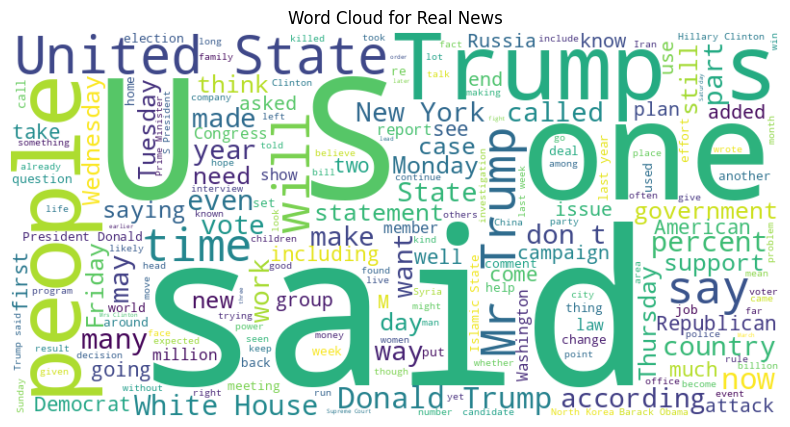

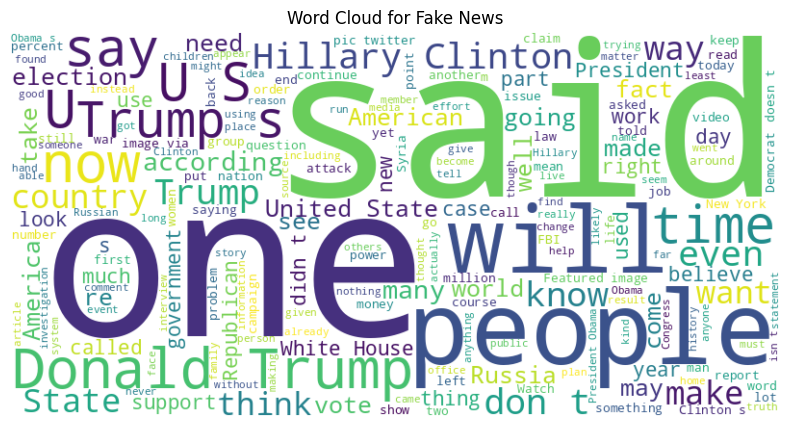

In [41]:
def plot_word_cloud(data, title):
    text_data = ' '.join(data.astype(str))
    if not text_data.strip():  
        print(f"No text data available for {title}")
        return
    
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text_data)
    
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title)
    plt.show()

# Generate word clouds for Real (label=1) and Fake (label=0) news
plot_word_cloud(df[df['label'] == 1]['text'], 'Word Cloud for Real News')
plot_word_cloud(df[df['label'] == 0]['text'], 'Word Cloud for Fake News')

In [30]:
df['article_length'] = df['text'].apply(lambda x: len(x.split()))
df.head()

,text,label,article_length
0,the head of a conservative republican faction ...,1,746
1,transgender people will be allowed for the fir...,1,396
2,the special counsel investigation of links bet...,1,454
3,trump campaign adviser george papadopoulos tol...,1,373
4,president donald trump called on the u.s. post...,1,849


In [ ]:
import plotly.express as px

# Tính độ dài trung bình của bài viết theo nhãn
article_length_avg = df.groupby('label')['article_length'].mean().reset_index()
article_length_avg.columns = ['label', 'avg_length'] 

# Map nhãn 0, 1 thành Fake, Real 
article_length_avg['label'] = article_length_avg['label'].map({0: 'Fake', 1: 'Real'})

print("Average article length by label:")
print(article_length_avg)

fig = px.bar(article_length_avg, 
             x='label', 
             y='avg_length',
             title='Average Article Length by News Type',
             labels={'label': 'News Type', 'avg_length': 'Average Length (words)'},
             color='label',
             color_discrete_map={'Fake': '#FF6B6B', 'Real': '#4ECDC4'}, 
             text='avg_length')  

fig.update_traces(texttemplate='%{text:.1f}',  
                  textposition='outside',
                  marker=dict(line=dict(color='#000000', width=1)))  

fig.update_layout(
    title=dict(text='Average Article Length by News Type', 
               font=dict(size=20, color='#333333'), 
               x=0.5, 
               xanchor='center'),  
    xaxis_title='News Type',
    yaxis_title='Average Length (words)',
    font=dict(family='Arial', size=14, color='#333333'), 
    plot_bgcolor='white',  
    paper_bgcolor='white',  
    xaxis=dict(
        showgrid=False, 
        title_font=dict(size=16),
        tickfont=dict(size=14)
    ),
    yaxis=dict(
        showgrid=True,  
        gridcolor='lightgrey',  
        gridwidth=1,
        title_font=dict(size=16),
        tickfont=dict(size=14)
    ),
    showlegend=False,  
    margin=dict(l=50, r=50, t=80, b=50), 
    height=500  
)

fig.show()